Installation

In [ ]:
%pip install "pandas<3.0.0" "google-genai" "python-dotenv" -U

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Loading GEMINI API KEY

In [1]:
from google import genai
import os
from dotenv import load_dotenv
# loading variables from .env file
load_dotenv() 

API_KEY = os.getenv('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY)

###**Bio Generation**

get speaker bio

In [2]:
import random
import time
from tqdm.auto import tqdm

def generate_global_bios(df):
    """Creates a dictionary of character summaries to give Gemini personality context."""
    bios = {}
    # We take a few sample lines for each speaker to 'prime' the model
    for speaker in df['Speaker'].unique():
        samples = df[df['Speaker'] == speaker]['Utterance'].head(10).tolist()
        samples_str = " ".join([f'"{s}"' for s in samples])
        bios[speaker] = f"{speaker} typically speaks like this: {samples_str}"
    return bios

c:\Users\jessi\SenticCrystal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def predict_dialogue_emotions(bios, dialogue_group):
    """Sends an entire dialogue to Gemini 2.5 and gets a list of emotions back."""
    # Ensure labels are alphabetical as per your preference
    valid_labels = ["Anger", "Disgust", "Fear", "Joy", "Neutral", "Sadness", "Surprise"]
    
    # Format the dialogue turns for the prompt
    turns = [f"Turn {i+1} - {r['Speaker']}: {r['Utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)
    
    # Filter bios to only those present in this specific dialogue
    relevant_bios = "\n".join([bios.get(s, "") for s in set(r['Speaker'] for r in dialogue_group)])

    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
Return a JSON list of strings. The length of the list must be exactly {len(dialogue_group)}.

SPEAKER CONTEXT:
{relevant_bios}

DIALOGUE TO ANALYZE:
{dialogue_text}

ALLOWED LABELS (Alphabetical): {valid_labels}

Output Format: ["Label1", "Label2", ...]"""

    # Using Gemini 2.5 Flash for speed and long-context reasoning
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={'response_mime_type': 'application/json'}
    )
    
    # Parse the JSON response
    try:
        import json
        predictions = json.loads(response.text)
        # Basic validation: ensure it's a list and matches length
        if not isinstance(predictions, list) or len(predictions) != len(dialogue_group):
            return ["Neutral"] * len(dialogue_group)
        return [p if p in valid_labels else "Neutral" for p in predictions]
    except:
        return ["Neutral"] * len(dialogue_group)

processing data

In [ ]:
import pandas as pd
def process_meld_batch(file_path, output_csv="hierarchical_results.csv"):
    df = pd.read_csv(file_path)
    df = df.sort_values(['Dialogue_ID', 'Utterance_ID'])

    processed_ids = set()
    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
        if not existing_df.empty:
            processed_ids = set(existing_df['Dialogue_ID'].unique())
            print(f"Skipping {len(processed_ids)} already processed dialogues.")
    
    bios = generate_global_bios(df)
    results = []
    grouped = df.groupby('Dialogue_ID')

    for diag_id, group in tqdm(grouped, desc="Processing Dialogues"):
        if diag_id in processed_ids:
            continue
        group_list = group.to_dict('records')
        
        # Get all predictions for this dialogue in ONE API call
        try:
            predictions = predict_dialogue_emotions(bios, group_list)
            
            curr_batch = []
            for i, row in enumerate(group_list):
                curr_batch.append({
                    'Dialogue_ID': diag_id,
                    'Utterance_ID': row['Utterance_ID'],
                    'Speaker': row['Speaker'],
                    'Original_Emotion': row['Emotion'],
                    'Predicted_Emotion': predictions[i] if i < len(predictions) else "Neutral"
                })
            
            new_df = pd.DataFrame(curr_batch)
            if not os.path.isfile(output_csv):
                new_df.to_csv(output_csv, index=False)
            else:
                new_df.to_csv(output_csv, mode='a', header=False, index=False)
            results.extend(curr_batch)
        except Exception as e:
            if "429" in str(e):
                print("\nQuota hit! Saving and exiting...")
                pd.DataFrame(results).to_csv(output_csv, index=False)
                return  # Exit gracefully so you can restart later
            print(f"Error at {diag_id}: {e}")

    return pd.DataFrame(results)

# Run it!
final_df = process_meld_batch(r"C:\Users\jessi\SenticCrystal\data\meld_7way_data\train_sent_emo.csv")

Skipping 95 already processed dialogues.


Processing Dialogues:  30%|██▉       | 311/1038 [45:26<3:08:55, 15.59s/it]

Error at 311: Server disconnected without sending a response.


Processing Dialogues: 100%|██████████| 1038/1038 [2:14:55<00:00,  7.80s/it] 


--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.52      0.60      0.56      1109
     disgust       0.30      0.34      0.32       271
        fear       0.35      0.41      0.37       268
         joy       0.56      0.61      0.59      1738
     neutral       0.76      0.73      0.75      4704
     sadness       0.54      0.44      0.48       683
    surprise       0.67      0.60      0.63      1203

    accuracy                           0.64      9976
   macro avg       0.53      0.53      0.53      9976
weighted avg       0.65      0.64      0.64      9976

Overall Weighted F1 Score: 0.6435


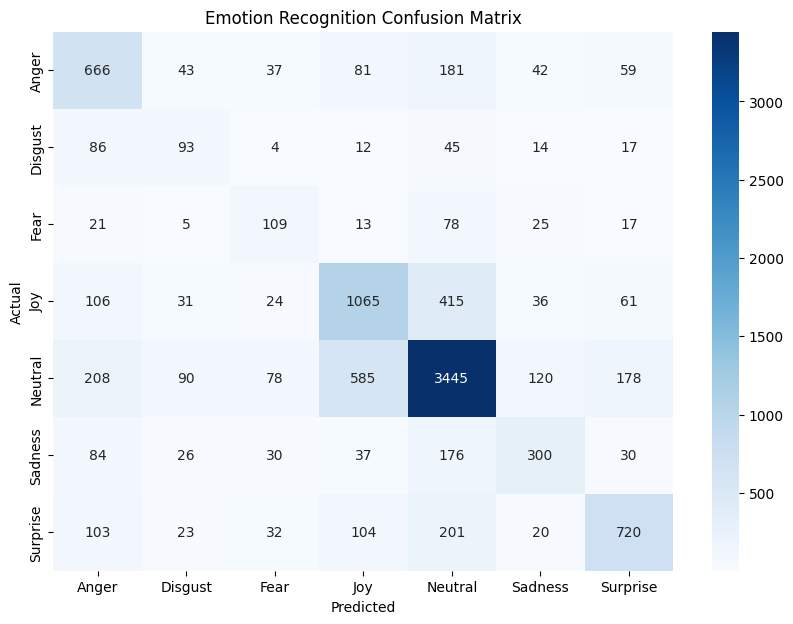

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_results(csv_file):
    df = pd.read_csv(csv_file)
    df['Predicted_Emotion'] = df['Predicted_Emotion'].astype(str).str.strip().str.lower()
    df['Original_Emotion'] = df['Original_Emotion'].astype(str).str.strip().str.lower()
    labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

    print("--- Classification Report ---")
    # Adding zero_division=0 hides the warnings for missing labels
    print(classification_report(df['Original_Emotion'], 
                                df['Predicted_Emotion'], 
                                labels=labels,
                                zero_division=0))

    weighted_f1 = f1_score(df['Original_Emotion'], 
                           df['Predicted_Emotion'], 
                           average='weighted')
    print(f"Overall Weighted F1 Score: {weighted_f1:.4f}")
    cm = confusion_matrix(df['Original_Emotion'], 
                          df['Predicted_Emotion'], 
                          labels=labels)
    
    plt.figure(figsize=(10, 7))
    display_labels = [l.capitalize() for l in labels]
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=display_labels, yticklabels=display_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()
evaluate_results("hierarchical_results.csv")

STOP HERE?
